# 1. Load inputs and fitted parameters

In [1]:
from pathlib import Path
from contextlib import ExitStack
import json
import numpy as np
import pandas as pd
from rasterio.io import MemoryFile
from affine import Affine
from importlib.metadata import version
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import rasterio
from rasterio.transform import rowcol, xy
from rasterio.windows import Window
from rasterio.warp import transform as transform_coords, reproject, Resampling
from scipy.spatial import cKDTree
from threadpoolctl import threadpool_limits
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display

import hashlib

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'field_evidence_support.ipynb').exists():
    candidates = list(NOTEBOOK_DIR.glob('*/field_evidence_support.ipynb'))
    if len(candidates) != 1:
        raise FileNotFoundError('Open Jupyter in the folder containing the notebooks.')
    NOTEBOOK_DIR = candidates[0].parent
OUTPUT_DIR = NOTEBOOK_DIR / 'cropland_raster_strata'
RASTER_OUTPUT_DIR = NOTEBOOK_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def verify_inputs(folder, records):
    for record in records:
        path = Path(folder) / record['name']
        if path.stat().st_size != record['bytes'] or sha256_file(path) != record['sha256']:
            raise ValueError(f'Input content changed: {path.name}; rerun sections 1-6.')

def raster_values_sha256(path):
    digest = hashlib.sha256()
    with rasterio.open(path) as src:
        for row in range(0, src.height, 128):
            window = Window(0, row, src.width, min(128, src.height - row))
            digest.update(src.read(1, window=window).astype('<i2').tobytes())
    return digest.hexdigest()

def restore_estimator(estimator, state):
    for name, value in state.items():
        if isinstance(value, dict) and 'array' in value:
            value = np.asarray(value['array'], dtype=value['dtype'])
        setattr(estimator, name, value)
    return estimator

def add_lonlat_grid(ax, bounds, crs):
    for lon in range(70, 141, 10):
        xs, ys = transform_coords('EPSG:4326', crs, np.full(600, lon), np.linspace(0, 65, 600))
        ax.plot(xs, ys, color='gray', linewidth=.5, alpha=.45)
        for j in range(len(ys) - 1):
            if ys[j] <= bounds.bottom < ys[j + 1]:
                x = xs[j] + (xs[j + 1] - xs[j]) * (bounds.bottom - ys[j]) / (ys[j + 1] - ys[j])
                if bounds.left <= x <= bounds.right:
                    ax.annotate(f'{lon}°E', (x, bounds.bottom), xytext=(0, -5),
                                textcoords='offset points', ha='center', va='top', fontsize=8)
    for lat in range(10, 61, 10):
        xs, ys = transform_coords('EPSG:4326', crs, np.linspace(50, 160, 800), np.full(800, lat))
        ax.plot(xs, ys, color='gray', linewidth=.5, alpha=.45)
        for j in range(len(xs) - 1):
            if xs[j] <= bounds.left < xs[j + 1]:
                y = ys[j] + (ys[j + 1] - ys[j]) * (bounds.left - xs[j]) / (xs[j + 1] - xs[j])
                if bounds.bottom <= y <= bounds.top:
                    ax.annotate(f'{lat}°N', (bounds.left, y), xytext=(-5, 0),
                                textcoords='offset points', ha='right', va='center', fontsize=8)
    ax.set(xlim=(bounds.left, bounds.right), ylim=(bounds.bottom, bounds.top))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('Longitude', labelpad=20)
    ax.set_ylabel('Latitude', labelpad=32)
    ax.set_aspect('equal')

state_path = OUTPUT_DIR / 'model_state.json'
if not state_path.exists():
    raise FileNotFoundError('Run sections 1-6 to generate meta_data_region.xlsx and model_state.json first.')
manifest = json.loads(state_path.read_text(encoding='utf-8'))
if manifest.get('schema_version') != 4:
    raise ValueError('Rerun sections 1-6 to update the model state.')
RASTER_DIR = (NOTEBOOK_DIR / manifest['raster_dir']).resolve()
if version('scikit-learn') != manifest['sklearn_version']:
    raise ValueError('Use the same scikit-learn version as sections 1-6.')
verify_inputs(RASTER_DIR, manifest['raster_inputs'])

ev_weight, ev_k = float(manifest['weight']), int(manifest['k'])
ev_output = OUTPUT_DIR
ev_raster_dir = RASTER_DIR

ev_tag = f'k{ev_k}_w{ev_weight:g}'
ev_parameters = manifest['fitted_parameters']
ev_scaler = restore_estimator(StandardScaler(), ev_parameters['scaler'])
ev_pca = restore_estimator(PCA(), ev_parameters['pca'])
ev_model = restore_estimator(KMeans(), ev_parameters['model'])
ev_features = manifest['features']
ev_label_map = np.asarray(manifest['label_map'], dtype='int16')
ev_crs = rasterio.crs.CRS.from_wkt(manifest['crs'])
ev_scale = float(manifest['spatial_scale_m'])
assert ev_model.n_clusters == ev_k
ev_region_ids = np.arange(1, ev_k + 1)
ev_site_path = NOTEBOOK_DIR / manifest['site_file']
ev_map_path = RASTER_OUTPUT_DIR / f'field_evidence_region_{ev_tag}_Albers.tif'
ev_records = pd.read_excel(ev_site_path, sheet_name='Records with regions')
ev_keys = ['Serial No.', 'Longitude', 'Latitude']
ev_site_digest = hashlib.sha256(ev_records[ev_keys + ['Region']]
    .to_json(orient='split', index=False, double_precision=15).encode('utf-8')).hexdigest()
if ev_site_digest != manifest['records_sha256']:
    raise ValueError('Region assignments changed; rerun sections 1-6.')
ev_sites_all = ev_records[ev_keys + ['Region']].drop_duplicates(ev_keys).reset_index(drop=True)
ev_saved_regions = ev_sites_all.pop('Region')
for feature in ev_features:
    with rasterio.open(ev_raster_dir / f'{feature}_cropped.tif') as src:
        sx, sy = transform_coords('EPSG:4326', src.crs, ev_sites_all.Longitude, ev_sites_all.Latitude)
        sampled = np.ma.vstack(list(src.sample(zip(sx, sy), indexes=1, masked=True)))[:, 0]
        ev_sites_all[feature] = sampled.astype(float).filled(np.nan)
ev_valid_sites = np.isfinite(ev_sites_all[ev_features].to_numpy(dtype=float)).all(axis=1)
ev_sites_all['Status'] = np.where(ev_valid_sites, 'assigned', 'missing raster features')
ev_sites_all['Region_ID'] = pd.to_numeric(ev_saved_regions.astype('string')
    .str.extract(r'^Region (\d+)$', expand=False), errors='coerce').astype('Int64')
ev_sites_all['Region'] = ev_saved_regions
for rid in ev_region_ids:
    ev_sites_all[f'Distance_to_Region_{rid}'] = np.nan
if ev_valid_sites.any():
    valid = ev_sites_all.loc[ev_valid_sites]
    pcs = ev_pca.transform(ev_scaler.transform(valid[ev_features].to_numpy(dtype=float)))
    mx, my = transform_coords('EPSG:4326', ev_crs, valid.Longitude, valid.Latitude)
    values = np.column_stack([pcs, np.sqrt(ev_weight) * np.column_stack([mx, my]) / ev_scale])
    distances = ev_model.transform(values)
    for label, rid in enumerate(ev_label_map):
        ev_sites_all.loc[ev_valid_sites, f'Distance_to_Region_{rid}'] = distances[:, label]
ev_feature_paths = [ev_raster_dir / f'{f}_cropped.tif' for f in ev_features]
ev_crop_path = ev_raster_dir / 'cropland_cropped.tif'
ev_good = (np.isfinite(ev_sites_all[ev_features].to_numpy(dtype=float)).all(axis=1)
           & ev_sites_all.Region_ID.isin(ev_region_ids))
ev_sites = ev_sites_all.loc[ev_good].copy()
if ev_sites.empty:
    raise ValueError('No valid field evidence sites; check section 6 inputs.')
ev_sites['Region_ID'] = ev_sites.Region_ID.astype(int)

# 2. Calibrate within-region evidence distances

In [2]:
with rasterio.open(ev_crop_path) as ev_ref:
    ev_source_shape, ev_source_crs, ev_source_transform = ev_ref.shape, ev_ref.crs, ev_ref.transform
    ev_source_profile = ev_ref.profile.copy()
    ev_sx, ev_sy = transform_coords('EPSG:4326', ev_ref.crs,
                                    ev_sites.Longitude.tolist(), ev_sites.Latitude.tolist())
    ev_rows, ev_cols = rowcol(ev_ref.transform, ev_sx, ev_sy)
ev_sites['Raster_row'], ev_sites['Raster_col'] = ev_rows, ev_cols
for ev_f, ev_path in zip(ev_features, ev_feature_paths):
    with rasterio.open(ev_path) as ev_src:
        assert ev_src.shape == ev_source_shape and ev_src.crs == ev_source_crs
        assert ev_src.transform.almost_equals(ev_source_transform)
        ev_sampled = np.ma.vstack(list(ev_src.sample(zip(ev_sx, ev_sy), masked=True)))[:, 0]
        if not np.allclose(ev_sampled.astype(float).filled(np.nan), ev_sites[ev_f], equal_nan=True):
            raise ValueError(f'{ev_f} differs from section 6 exports; rerun section 6.')
ev_all_pcs = ev_pca.transform(ev_scaler.transform(ev_sites[ev_features].to_numpy(dtype=float)))
ev_axm, ev_aym = transform_coords('EPSG:4326', ev_crs, ev_sites.Longitude.tolist(), ev_sites.Latitude.tolist())
ev_check_input = np.column_stack([ev_all_pcs, np.sqrt(ev_weight) * np.column_stack([ev_axm, ev_aym]) / ev_scale])
assert np.array_equal(ev_label_map[ev_model.predict(ev_check_input)], ev_sites.Region_ID.to_numpy()), 'Rerun section 6 to update site assignments.'
ev_group_keys = ['Region_ID', 'Raster_row', 'Raster_col']
ev_groups = ev_sites.groupby(ev_group_keys, sort=False)
ev_units = ev_groups.first().reset_index()
ev_units['Site_record_count'] = ev_groups.size().to_numpy()
ev_units['Serial Nos.'] = ev_groups['Serial No.'].agg(lambda x: ', '.join(map(str, pd.unique(x)))).to_numpy()
ev_units['Evidence_unit_ID'] = np.arange(1, len(ev_units) + 1)
ev_pc_names = [f'PC{i + 1}' for i in range(ev_pca.n_components_)]
ev_unit_pcs = ev_pca.transform(ev_scaler.transform(ev_units[ev_features].to_numpy(dtype=float)))
ev_units[ev_pc_names] = ev_unit_pcs
ev_units['LOO_distance'] = np.nan
ev_units['LOO_nearest_unit_ID'] = pd.Series(pd.NA, index=ev_units.index, dtype='Int64')
ev_trees, ev_thresholds, ev_calibration_rows = {}, {}, []
for ev_rid in ev_region_ids:
    ev_indices = np.flatnonzero(ev_units.Region_ID.to_numpy() == ev_rid)
    ev_n = len(ev_indices)
    ev_q = np.full(3, np.nan)
    if ev_n:
        ev_env = ev_unit_pcs[ev_indices]
        ev_trees[ev_rid] = cKDTree(ev_env)
    if ev_n >= 2:
        # k=2: nearest is self; second distance is the nearest OTHER evidence unit.
        # With exact environmental ties both distances can legitimately be zero.
        ev_dd, ev_jj = ev_trees[ev_rid].query(ev_env, k=2)
        ev_other = np.where(ev_jj[:, 0] != np.arange(ev_n), ev_jj[:, 0], ev_jj[:, 1])
        ev_loo = np.linalg.norm(ev_env - ev_env[ev_other], axis=1)
        ev_brute = np.linalg.norm(ev_env[:, None, :] - ev_env[None, :, :], axis=2)
        np.fill_diagonal(ev_brute, np.inf)
        np.testing.assert_allclose(ev_loo, ev_brute.min(axis=1), atol=1e-12)
        ev_units.loc[ev_indices, 'LOO_distance'] = ev_loo
        ev_units.loc[ev_indices, 'LOO_nearest_unit_ID'] = ev_units.Evidence_unit_ID.to_numpy()[ev_indices[ev_other]]
        ev_q = np.quantile(ev_loo, [.5, .9, .99], method='linear')
        ev_thresholds[ev_rid] = ev_q
    ev_calibration_rows.append({'Region_ID': int(ev_rid),
        'Site_records': int((ev_sites.Region_ID == ev_rid).sum()), 'Independent_raster_units': ev_n,
        'Q50': ev_q[0], 'Q90': ev_q[1], 'Q99': ev_q[2],
        'Zero_LOO_count': int((ev_units.loc[ev_indices, 'LOO_distance'] == 0).sum()),
        'Calibration_status': 'calibrated' if ev_n >= 2 else ('no sites' if ev_n == 0 else 'one unit: uncalibrated')})
ev_calibration = pd.DataFrame(ev_calibration_rows)
ev_sites = ev_sites.merge(ev_units[ev_group_keys + ['Evidence_unit_ID']], on=ev_group_keys, how='left', validate='many_to_one')
print(f'K={ev_k}, weight={ev_weight:g}; {len(ev_sites)} valid site records -> {len(ev_units)} independent environmental raster units.', flush=True)
display(ev_calibration)

# Evidence distance uses ONLY PCA coordinates. Spatial weight is used ONLY for region assignment.
# Classes: 0 NoData/noncropland; 1 High; 2 Moderate; 3 Limited; 4 Unsupported;
#          5 Uncalibrated (only one independent evidence unit in a region).
ev_names = {1: 'High', 2: 'Moderate', 3: 'Limited', 4: 'Unsupported', 5: 'Uncalibrated'}
def ev_support_class(distances, quantiles):
    q50, q90, q99 = quantiles
    return np.where(distances <= q50, 1, np.where(distances <= q90, 2,
                    np.where(distances <= q99, 3, 4))).astype('uint8')


K=3, weight=1; 150 valid site records -> 131 independent environmental raster units.


,Region_ID,Site_records,Independent_raster_units,Q50,Q90,Q99,Zero_LOO_count,Calibration_status
0,1,18,13,0.482089,0.735807,1.056095,0,calibrated
1,2,64,54,0.420083,0.849676,1.754424,0,calibrated
2,3,68,64,0.420611,0.826649,1.514861,0,calibrated


# 3. Predict and align the evidence rasters

In [3]:
with ExitStack() as ev_memory:
    ev_source_memory = {key: ev_memory.enter_context(MemoryFile())
                        for key in ['distance', 'support', 'region']}
    ev_source_paths = {key: mem.name for key, mem in ev_source_memory.items()}
    ev_albers_paths = {key: RASTER_OUTPUT_DIR / f'field_evidence_{key}_{ev_tag}_Albers.tif'
                       for key in ev_source_paths}
    ev_profiles = {}
    for ev_key in ev_source_paths:
        ev_pr = ev_source_profile.copy()
        ev_pr.update(count=1, dtype='float32' if ev_key == 'distance' else 'int16',
                     nodata=-9999.0 if ev_key == 'distance' else 0,
                     compress='lzw', predictor=3 if ev_key == 'distance' else 2)
        ev_profiles[ev_key] = ev_pr
    ev_counts = np.zeros((ev_k, 5), dtype=np.int64)
    ev_areas = np.zeros((ev_k, 5), dtype=float)
    with ExitStack() as ev_stack, threadpool_limits(limits=4):
        ev_sources = [ev_stack.enter_context(rasterio.open(p)) for p in ev_feature_paths]
        ev_crop = ev_stack.enter_context(rasterio.open(ev_crop_path))
        ev_writers = {key: ev_stack.enter_context(rasterio.open(path, 'w', **ev_profiles[key]))
                      for key, path in ev_source_paths.items()}
        for ev_row in range(0, ev_source_shape[0], 64):
            ev_height = min(64, ev_source_shape[0] - ev_row)
            ev_window = Window(0, ev_row, ev_source_shape[1], ev_height)
            ev_crop_data = ev_crop.read(1, window=ev_window, masked=True)
            ev_values = np.ma.column_stack([src.read(1, window=ev_window, masked=True).ravel() for src in ev_sources])
            ev_valid = ((~np.ma.getmaskarray(ev_crop_data).ravel()) & (ev_crop_data.data.ravel() > 0)
                        & (~np.ma.getmaskarray(ev_values).any(axis=1)) & np.isfinite(ev_values.data).all(axis=1))
            ev_dist_out = np.full(ev_valid.size, -9999.0, dtype='float32')
            ev_sup_out = np.zeros(ev_valid.size, dtype='uint8')
            ev_reg_out = np.zeros(ev_valid.size, dtype='uint8')
            if ev_valid.any():
                ev_pcs = ev_pca.transform(ev_scaler.transform(ev_values.data[ev_valid].astype(float)))
                ev_positions = np.flatnonzero(ev_valid)
                ev_rr, ev_cc = np.divmod(ev_positions, ev_source_shape[1])
                ev_gx, ev_gy = xy(ev_source_transform, ev_rr + ev_row, ev_cc, offset='center')
                ev_mx, ev_my = transform_coords(ev_source_crs, ev_crs, ev_gx, ev_gy)
                ev_cluster_values = np.column_stack([ev_pcs, np.sqrt(ev_weight) * np.column_stack([ev_mx, ev_my]) / ev_scale])
                ev_regions = ev_label_map[ev_model.predict(ev_cluster_values)]
                ev_reg_out[ev_positions] = ev_regions
                for ev_rid in ev_region_ids:
                    ev_use = ev_regions == ev_rid
                    if not ev_use.any():
                        continue
                    ev_pos = ev_positions[ev_use]
                    if ev_rid not in ev_trees:
                        ev_support = np.full(ev_use.sum(), 4, dtype='uint8')
                    else:
                        ev_dist, _ = ev_trees[ev_rid].query(ev_pcs[ev_use], k=1)
                        ev_dist_out[ev_pos] = ev_dist.astype('float32')
                        ev_support = (ev_support_class(ev_dist, ev_thresholds[ev_rid]) if ev_rid in ev_thresholds
                                      else np.full(ev_use.sum(), 5, dtype='uint8'))
                    ev_sup_out[ev_pos] = ev_support
                    ev_counts[ev_rid - 1] += np.bincount(ev_support, minlength=6)[1:6]
                    ev_areas[ev_rid - 1] += np.bincount(ev_support,
                        weights=ev_crop_data.data.ravel()[ev_pos], minlength=6)[1:6]
            for ev_key, ev_array in [('distance', ev_dist_out), ('support', ev_sup_out), ('region', ev_reg_out)]:
                ev_writers[ev_key].write(ev_array.reshape(ev_height, ev_source_shape[1]), 1, window=ev_window)
            if ev_row % 640 == 0:
                print(f'Cropland PCA nearest-neighbour distances: {ev_row + ev_height}/{ev_source_shape[0]} rows', flush=True)

    # Match categorical reprojection and source-pixel indices across outputs.
    # Float distances are gathered via int16 source row/column maps so every output
    # uses the SAME original pixel, even at warp chunk boundaries.
    ev_grid = manifest['classification_grid']
    ev_target_transform = Affine(*ev_grid['transform'])
    ev_target_shape = (ev_grid['height'], ev_grid['width'])
    ev_target_crs = rasterio.crs.CRS.from_wkt(ev_grid['crs'])
    for ev_key, ev_path in ev_albers_paths.items():
        if ev_key == 'distance':
            continue
        ev_pr = ev_profiles[ev_key].copy()
        ev_pr.update(crs=ev_target_crs, transform=ev_target_transform,
                     height=ev_target_shape[0], width=ev_target_shape[1])
        with rasterio.open(ev_source_paths[ev_key]) as ev_src, rasterio.open(ev_path, 'w', **ev_pr) as ev_dst:
            reproject(source=rasterio.band(ev_src, 1), destination=rasterio.band(ev_dst, 1),
                      src_transform=ev_src.transform, src_crs=ev_src.crs, src_nodata=ev_src.nodata,
                      dst_transform=ev_target_transform, dst_crs=ev_target_crs,
                      dst_nodata=ev_dst.nodata, resampling=Resampling.nearest)
            ev_dst.update_tags(metric='Euclidean PCA distance within same region only',
                               spatial_weight=str(ev_weight), k=str(ev_k),
                               calibration='LOO within region; unique source raster cells; Q50 Q90 Q99',
                               support_codes=json.dumps(ev_names), alignment_version='2')
    if raster_values_sha256(ev_map_path) != manifest['classification_sha256']:
        raise ValueError('Regenerated regions differ from the section 6 classification.')

    ev_index_paths = []
    assert max(ev_source_shape) < np.iinfo('int16').max
    for ev_axis in ['row', 'col']:
        ev_index_source = ev_memory.enter_context(MemoryFile()).name
        ev_index_target = ev_memory.enter_context(MemoryFile()).name
        ev_index_paths.extend([ev_index_source, ev_index_target])
        with rasterio.open(ev_source_paths['region']) as ev_src, rasterio.open(ev_index_source, 'w', **ev_profiles['region']) as ev_dst:
            for ev_row in range(0, ev_source_shape[0], 64):
                ev_height = min(64, ev_source_shape[0]-ev_row)
                ev_win = Window(0, ev_row, ev_source_shape[1], ev_height)
                ev_mask = ev_src.read(1, window=ev_win) > 0
                ev_index = (np.arange(ev_row+1, ev_row+ev_height+1, dtype='int16')[:,None] if ev_axis == 'row'
                            else np.arange(1, ev_source_shape[1]+1, dtype='int16')[None,:])
                ev_dst.write(np.where(ev_mask, ev_index, 0).astype('int16'), 1, window=ev_win)
        ev_pr = ev_profiles['region'].copy()
        ev_pr.update(crs=ev_target_crs, transform=ev_target_transform, height=ev_target_shape[0], width=ev_target_shape[1])
        with rasterio.open(ev_index_source) as ev_src, rasterio.open(ev_index_target, 'w', **ev_pr) as ev_dst:
            reproject(source=rasterio.band(ev_src,1), destination=rasterio.band(ev_dst,1),
                      src_transform=ev_src.transform, src_crs=ev_src.crs, src_nodata=0,
                      dst_transform=ev_target_transform, dst_crs=ev_target_crs, dst_nodata=0,
                      resampling=Resampling.nearest)
    with rasterio.open(ev_source_paths['distance']) as ev_src:
        ev_source_distances = ev_src.read(1)
    with rasterio.open(ev_source_paths['region']) as ev_src:
        ev_source_regions = ev_src.read(1)
    ev_pr = ev_profiles['distance'].copy()
    ev_pr.update(crs=ev_target_crs, transform=ev_target_transform, height=ev_target_shape[0], width=ev_target_shape[1])
    with rasterio.open(ev_index_paths[1]) as ev_row_src, rasterio.open(ev_index_paths[3]) as ev_col_src, rasterio.open(ev_map_path) as ev_base, rasterio.open(ev_albers_paths['distance'], 'w', **ev_pr) as ev_dst:
        for ev_row in range(0, ev_target_shape[0], 128):
            ev_win = Window(0, ev_row, ev_target_shape[1], min(128, ev_target_shape[0]-ev_row))
            ev_rr = ev_row_src.read(1, window=ev_win).astype('int32') - 1
            ev_cc = ev_col_src.read(1, window=ev_win).astype('int32') - 1
            ev_b = ev_base.read(1, window=ev_win)
            ev_ok = (ev_rr >= 0) & (ev_cc >= 0)
            assert np.array_equal(ev_ok, ev_b > 0), 'Source index mask differs from original classification'
            assert np.array_equal(ev_source_regions[ev_rr[ev_ok], ev_cc[ev_ok]], ev_b[ev_ok]), 'Source region differs from original classification'
            ev_dist_block = np.full(ev_b.shape, -9999., dtype='float32')
            ev_dist_block[ev_ok] = ev_source_distances[ev_rr[ev_ok], ev_cc[ev_ok]]
            ev_dst.write(ev_dist_block, 1, window=ev_win)
        ev_dst.update_tags(metric='Euclidean PCA nearest neighbour in same region only', k=str(ev_k),
                           spatial_weight_for_region=str(ev_weight), alignment_version='2',
                           alignment='int16 nearest-neighbour source index mapping identical to classification map')
    del ev_source_distances, ev_source_regions

    # Validate full map alignment, masks, and the no-cross-region classification.
    ev_map_counts = np.zeros((ev_k, 5), dtype=np.int64)
    with rasterio.open(ev_map_path) as ev_base, rasterio.open(ev_albers_paths['region']) as ev_reg, rasterio.open(ev_albers_paths['support']) as ev_sup:
        for ev_row in range(0, ev_target_shape[0], 128):
            ev_win = Window(0, ev_row, ev_target_shape[1], min(128, ev_target_shape[0]-ev_row))
            ev_b, ev_r, ev_s = (src.read(1, window=ev_win) for src in [ev_base, ev_reg, ev_sup])
            if not np.array_equal(ev_b, ev_r):
                raise ValueError('Computed regions differ from the classification raster; check model and input versions.')
            assert np.array_equal(ev_s > 0, ev_b > 0)
            for ev_rid in ev_region_ids:
                ev_map_counts[ev_rid-1] += np.bincount(ev_s[ev_b == ev_rid], minlength=6)[1:6]


Cropland PCA nearest-neighbour distances: 64/4268 rows
Cropland PCA nearest-neighbour distances: 704/4268 rows
Cropland PCA nearest-neighbour distances: 1344/4268 rows
Cropland PCA nearest-neighbour distances: 1984/4268 rows
Cropland PCA nearest-neighbour distances: 2624/4268 rows
Cropland PCA nearest-neighbour distances: 3264/4268 rows
Cropland PCA nearest-neighbour distances: 3904/4268 rows


# 4. Export evidence tables

In [4]:
ev_summary_rows = []
for ev_rid in ev_region_ids:
    for ev_code, ev_name in ev_names.items():
        ev_summary_rows.append({'Region_ID': int(ev_rid), 'Support_code': ev_code, 'Support': ev_name,
            'Source_pixel_count': int(ev_counts[ev_rid-1, ev_code-1]),
            'Source_pixel_share': float(ev_counts[ev_rid-1, ev_code-1] / max(1, ev_counts[ev_rid-1].sum())),
            'Cropland_area_km2': float(ev_areas[ev_rid-1, ev_code-1]/1e6),
            'Cropland_area_share': float(ev_areas[ev_rid-1, ev_code-1] / max(1., ev_areas[ev_rid-1].sum())),
            'Albers_pixel_count': int(ev_map_counts[ev_rid-1, ev_code-1])})
ev_summary = pd.DataFrame(ev_summary_rows)
ev_excel_path = ev_output / 'field_evidence_results.xlsx'
with pd.ExcelWriter(ev_excel_path, engine='openpyxl') as ev_writer:
    ev_calibration.to_excel(ev_writer, sheet_name='Region thresholds', index=False)
    ev_units.to_excel(ev_writer, sheet_name='LOO evidence units', index=False)
    ev_sites.to_excel(ev_writer, sheet_name='Site to unit mapping', index=False)
    ev_sites_all.loc[~ev_good].to_excel(ev_writer, sheet_name='Excluded sites', index=False)
    ev_summary.to_excel(ev_writer, sheet_name='Support summary', index=False)
    pd.DataFrame({'Parameter': ['K','Spatial weight for region only','Distance space','Site features',
                               'LOO unit','Quantiles','Quantile method','Unsupported','Uncalibrated',
                               'Raster NoData','Distance NoData','Area source','Interpretation'],
                  'Value': [ev_k, ev_weight, 'Saved PCA; no spatial coordinates', str(ev_site_path),
                            'Unique region + source raster row/column', '0.50, 0.90, 0.99', 'linear',
                            'D > Q99 or no field sites in region', 'Only one independent unit; no LOO calibration',
                            'Support 0 = noncropland or invalid features', '-9999 = invalid or region with no sites',
                            'Sum of cropland_cropped.tif values in m2 on source grid',
                            'Relative environmental coverage, not a prediction accuracy or probability guarantee']
                 }).to_excel(ev_writer, sheet_name='Evidence method', index=False)

# 5. Visualize evidence support

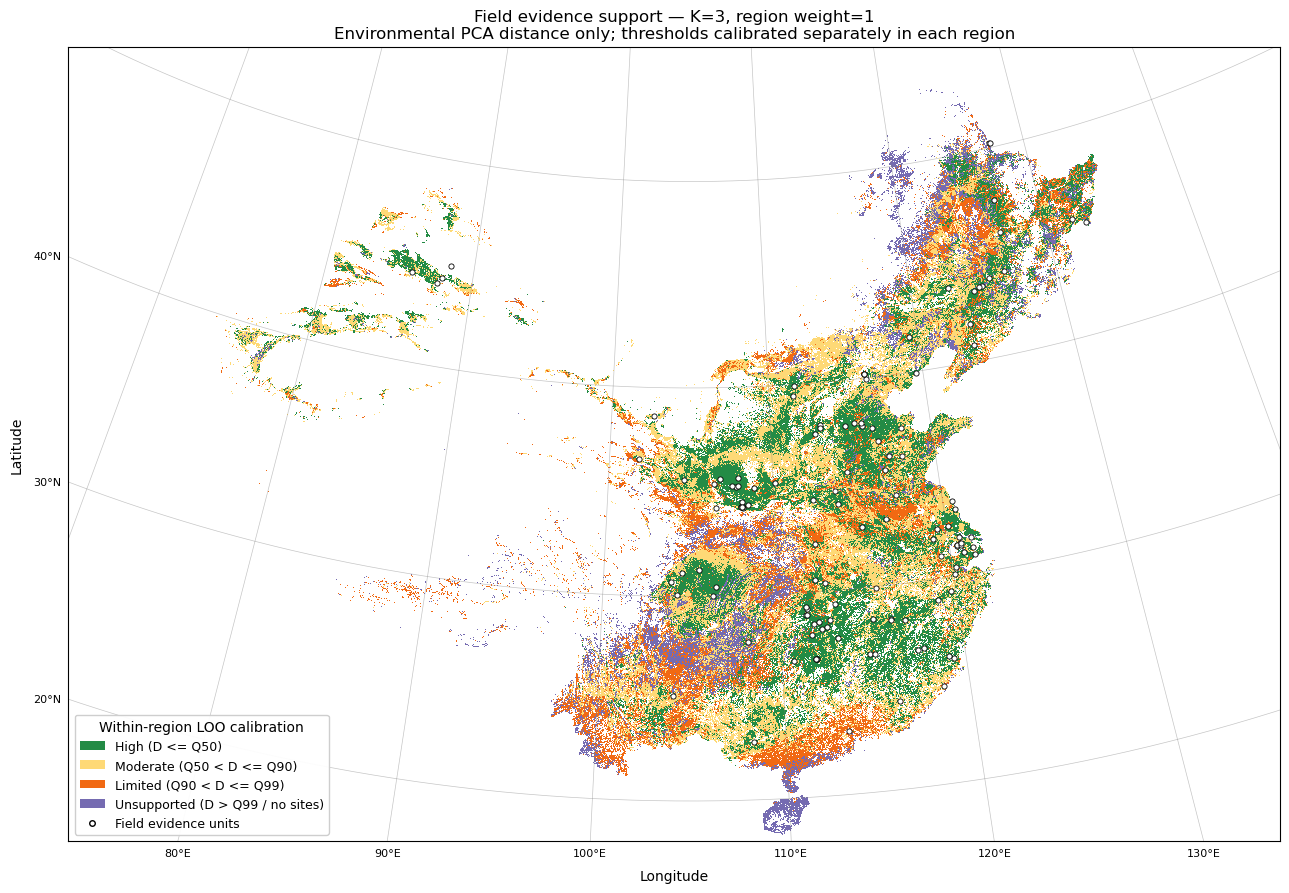

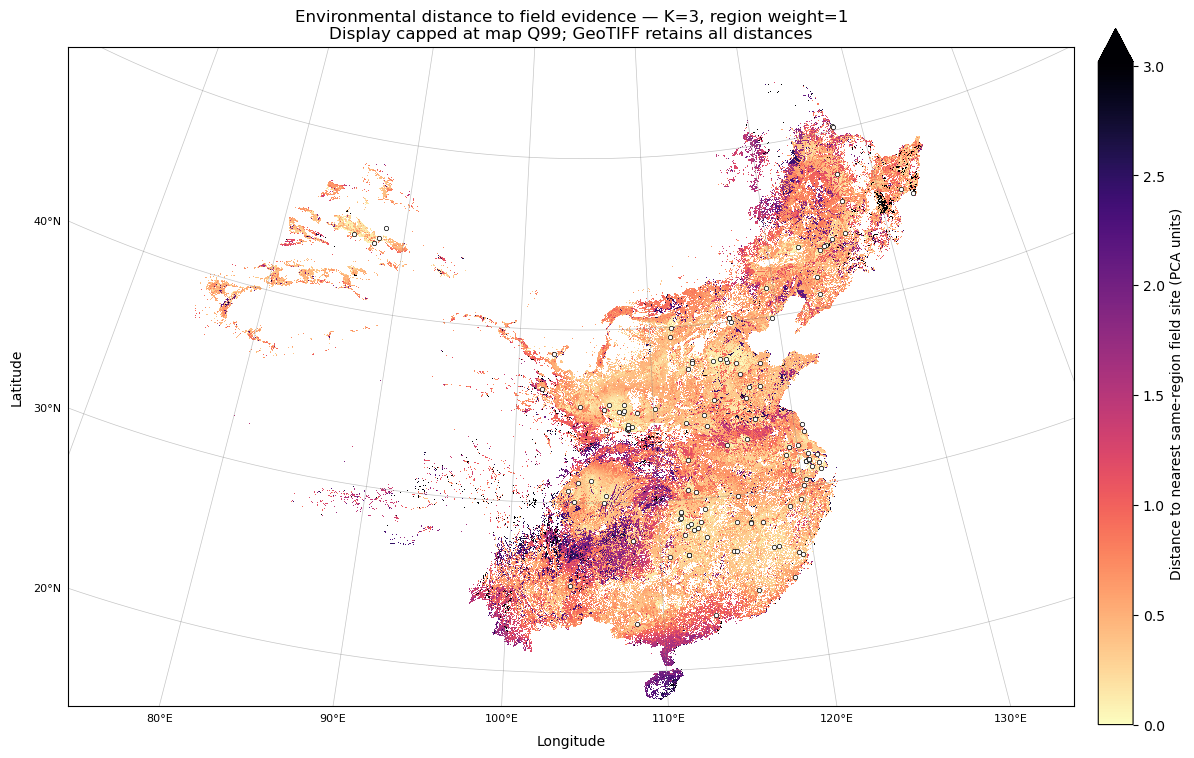

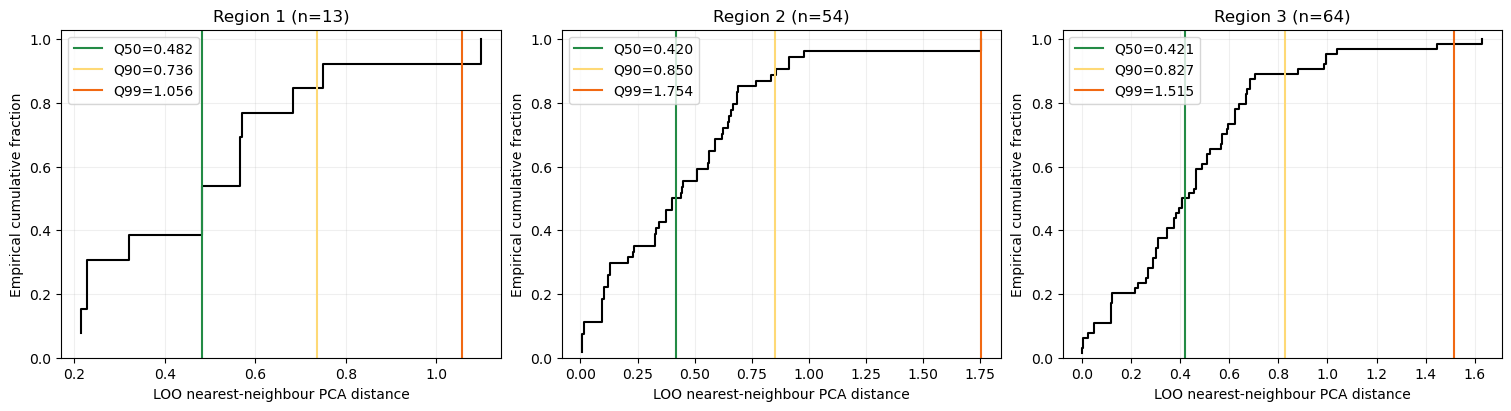

,Region_ID,Support_code,Support,Source_pixel_count,Source_pixel_share,Cropland_area_km2,Cropland_area_share,Albers_pixel_count
0,1,1,High,244784,0.241147,164335.3580,0.277806,147293
1,1,2,Moderate,203642,0.200616,127242.7354,0.215101,123828
2,1,3,Limited,226304,0.222941,142292.3953,0.240543,135434
3,1,4,Unsupported,340354,0.335296,157677.2530,0.266550,205034
4,1,5,Uncalibrated,0,0.000000,0.0000,0.000000,0
5,2,1,High,732311,0.368476,461794.7185,0.388809,493548
6,2,2,Moderate,942545,0.474259,549278.5057,0.462466,628530
7,2,3,Limited,267908,0.134803,149143.1095,0.125571,183163
8,2,4,Unsupported,44643,0.022463,27499.1707,0.023153,30381
9,2,5,Uncalibrated,0,0.000000,0.0000,0.000000,0


Calibration and support summary: c:\Meta\data_SD\meta_test\cropland_raster_strata\field_evidence_results.xlsx
Albers GeoTIFF: {'distance': 'c:\\Meta\\data_SD\\meta_test\\field_evidence_distance_k3_w1_Albers.tif', 'support': 'c:\\Meta\\data_SD\\meta_test\\field_evidence_support_k3_w1_Albers.tif', 'region': 'c:\\Meta\\data_SD\\meta_test\\field_evidence_region_k3_w1_Albers.tif'}
Validation passed: LOO agrees with brute-force distances; full-map regions and masks agree with the classification.


In [5]:
ev_palette = ['#238b45', '#fed976', '#f16913', '#756bb1', '#969696']
with rasterio.open(ev_albers_paths['support']) as ev_src:
    ev_support_map, ev_bounds = ev_src.read(1, masked=True), ev_src.bounds
ev_extent = [ev_bounds.left, ev_bounds.right, ev_bounds.bottom, ev_bounds.top]
ev_plot_x, ev_plot_y = transform_coords('EPSG:4326', ev_target_crs, ev_units.Longitude.tolist(), ev_units.Latitude.tolist())
ev_fig, ev_ax = plt.subplots(figsize=(13, 9))
ev_ax.imshow(ev_support_map, cmap=ListedColormap(ev_palette), norm=BoundaryNorm(np.arange(.5,6.5),5),
             extent=ev_extent, interpolation='nearest')
add_lonlat_grid(ev_ax, ev_bounds, ev_target_crs)
ev_ax.scatter(ev_plot_x, ev_plot_y, s=14, facecolor='white', edgecolor='black', linewidth=.6, zorder=5)
ev_legend_labels = ['High (D <= Q50)', 'Moderate (Q50 < D <= Q90)', 'Limited (Q90 < D <= Q99)',
                    'Unsupported (D > Q99 / no sites)', 'Uncalibrated (one unit)']
ev_handles = [Patch(facecolor=ev_palette[i-1], label=ev_legend_labels[i-1]) for i in ev_names
              if ev_map_counts[:,i-1].sum() > 0]
ev_handles.append(plt.Line2D([],[], marker='o', linestyle='', markerfacecolor='white', markeredgecolor='black', markersize=4, label='Field evidence units'))
ev_ax.legend(handles=ev_handles, loc='lower left', fontsize=9, title='Within-region LOO calibration', framealpha=.95)
ev_ax.set_title(f'Field evidence support — K={ev_k}, region weight={ev_weight:g}\nEnvironmental PCA distance only; thresholds calibrated separately in each region')
ev_fig.tight_layout()
plt.show()

with rasterio.open(ev_albers_paths['distance']) as ev_src:
    ev_distance_map = ev_src.read(1, masked=True)
ev_fig, ev_ax = plt.subplots(figsize=(13,9))
ev_vmax = float(np.quantile(ev_distance_map.compressed(), .99)) if ev_distance_map.count() else 1.
ev_im = ev_ax.imshow(ev_distance_map, cmap='magma_r', vmin=0, vmax=max(ev_vmax, 1e-6), extent=ev_extent, interpolation='nearest')
add_lonlat_grid(ev_ax, ev_bounds, ev_target_crs)
ev_ax.scatter(ev_plot_x, ev_plot_y, s=10, facecolor='white', edgecolor='black', linewidth=.5, zorder=5)
ev_fig.colorbar(ev_im, ax=ev_ax, shrink=.8, pad=.02, extend='max', label='Distance to nearest same-region field site (PCA units)')
ev_ax.set_title(f'Environmental distance to field evidence — K={ev_k}, region weight={ev_weight:g}\nDisplay capped at map Q99; GeoTIFF retains all distances')
ev_fig.tight_layout()
plt.show()

ev_fig, ev_axes = plt.subplots(1, ev_k, figsize=(5*ev_k,4), squeeze=False, constrained_layout=True)
for ev_ax, ev_rid in zip(ev_axes.ravel(), ev_region_ids):
    ev_loo_sorted = np.sort(ev_units.loc[ev_units.Region_ID == ev_rid, 'LOO_distance'].dropna().to_numpy())
    if len(ev_loo_sorted):
        ev_ax.step(ev_loo_sorted, np.arange(1,len(ev_loo_sorted)+1)/len(ev_loo_sorted), where='post', color='black')
        for ev_q, ev_label, ev_color in zip(ev_thresholds[ev_rid], ['Q50','Q90','Q99'], ev_palette[:3]):
            ev_ax.axvline(ev_q, color=ev_color, label=f'{ev_label}={ev_q:.3f}')
        ev_ax.legend()
    ev_ax.set(title=f'Region {ev_rid} (n={len(ev_loo_sorted)})', xlabel='LOO nearest-neighbour PCA distance', ylabel='Empirical cumulative fraction', ylim=(0,1.03))
    ev_ax.grid(alpha=.2)
plt.show()
display(ev_summary)
print('Calibration and support summary:', ev_excel_path)
print('Albers GeoTIFF:', {key: str(path) for key,path in ev_albers_paths.items()})
print('Validation passed: LOO agrees with brute-force distances; full-map regions and masks agree with the classification.')
